## Preamble

#### Description

This dataset is NASA's "OMNI 2" dataset. It stores a time-series collection of data obtained from spacecraft orbiting Earth, such as magnetic field activity, solar winds, etc [1]. We will first perform exploratory data analysis and select a certain parts of the data to use. Then, we will train two clustering algorithms: a _K_-Means classifier and a _K_-Medians classifier. We conclude with a discussion of the results.

#### Imports

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import RobustScaler

### 1. Dataset Exploration + Cleaning

In [10]:
omni_data = pd.read_csv('omni_data.csv')
#The dataset includes an unnecessary index column named 'Unnamed: 0', which we will remove before proceeding with our analysis.
omni_data = omni_data.drop(columns=['Unnamed: 0'])

#Getting basic information like column names and data types
print(omni_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482136 entries, 0 to 482135
Data columns (total 55 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   year                      482136 non-null  int64  
 1   day                       482136 non-null  float64
 2   hour                      482136 non-null  float64
 3   Bartels_rotation_num      482136 non-null  int64  
 4   id_IMF_sc                 482136 non-null  int64  
 5   id_SW_plasma_sc           358100 non-null  float64
 6   #IMF_avg                  482136 non-null  int64  
 7   #plasma_avg               482136 non-null  int64  
 8   field_mag_avg             482136 non-null  float64
 9   mag_avg_field_vec         482136 non-null  float64
 10  lat_angle_avg_field_vec   482136 non-null  float64
 11  long_angle_avg_field_vec  482136 non-null  float64
 12  Bx_GSE_GSM                482136 non-null  float64
 13  By_GSE                    482136 non-null  f

We can see, all of our features are numerical. The dataset includes 55 columns, 3 of which are time (year, day, and hour). 

Reading the documentation for OMNI data [1], we find that missing values are represented by specific fill values for each column. We will replace these fill values with NaN for easier handling of missing data.

In [ ]:
fill_values = {
    "Bartels_rotation_num": 9999,
    "id_IMF_sc": 99,
    "id_SW_plasma_sc": 99,
    "#IMF_avg": 999,
    "#plasma_avg": 999,
    
    # 999.9 values
    "field_mag_avg": 999.9,
    "mag_avg_field_vec": 999.9,
    "lat_angle_avg_field_vec": 999.9,
    "long_angle_avg_field_vec": 999.9,
    "Bx_GSE_GSM": 999.9,
    "By_GSE": 999.9,
    "Bz_GSE": 999.9,
    "By_GSM": 999.9,
    "Bz_GSM": 999.9,
    "sigma_|B|": 999.9,
    "sigma_B": 999.9,
    "sigma_Bx": 999.9,
    "sigma_By": 999.9,
    "sigma_Bz": 999.9,

    # temperature / density / velocity
    "proton_temp": 9999999.0,
    "proton_density": 999.9,
    "plasma_flow_speed": 9999.0,
    "plasma_flow_long_angle": 999.9,
    "plasma_flow_lat_angle": 999.9,

    "Na/Np": 9.999,
    "flow_pressure": 99.99,

    "sigma_T": 9999999.0,
    "sigma_N": 999.9,
    "sigma_V": 9999.0,
    "sigma_phi_V": 999.9,
    "sigma_theta_V": 999.9,
    "sigma-Na/Np": 9.999,

    "Electric_field": 999.99,
    "plasma_beta": 999.99,
    "Alfven_mach_num": 999.9,

    "Kp": 99,
    "R": 999,
    "dst": 99999,
    "AE_index": 9999,

    # Proton flux (PF, PF.1, PF.2, PF.3, PF.4, PF.5)
    "PF": 999999.99,
    "PF.1": 99999.99,
    "PF.2": 99999.99,
    "PF.3": 99999.99,
    "PF.4": 99999.99,
    "PF.5": 99999.99,

    "ap_index": 999,
    "f10.7_index": 999.9,
    "PC(N)_index": 999.9,
    "AL_index_kyoto": 99999,
    "AU_index_kyoto": 99999,
    "magnetosonic_mach num": 99.9,
}
df = omni_data.copy()
for col, fv in fill_values.items():
    if col in df.columns:
        #Replace fill values with NaN
        df[col] = df[col].replace(fv, np.nan)       
omni_data = df
omni_data.isna().mean().sort_values(ascending=False).head(55)


PF.2                        0.590804
PF.1                        0.590802
PF                          0.515257
Na/Np                       0.454882
sigma-Na/Np                 0.454882
sigma_theta_V               0.432544
plasma_flow_lat_angle       0.403712
sigma_phi_V                 0.361021
magnetosonic_mach num       0.358542
plasma_beta                 0.358542
sigma_N                     0.336121
sigma_T                     0.334433
sigma_V                     0.330631
plasma_flow_long_angle      0.329739
proton_temp                 0.326622
Alfven_mach_num             0.325779
id_SW_plasma_sc             0.313712
Electric_field              0.313150
#IMF_avg                    0.301591
#plasma_avg                 0.294925
flow_pressure               0.291704
proton_density              0.291704
sigma_|B|                   0.291389
PF.5                        0.282400
PF.4                        0.282371
PF.3                        0.282302
PC(N)_index                 0.273456
p

The dataset contains a significant amount of missing data in several columns. We will first conduct exploratory data anlaysis ignoring the NaN value, and then make an informed decision about filling the NaN values.

Let's see how the number of missing values varies over the years.

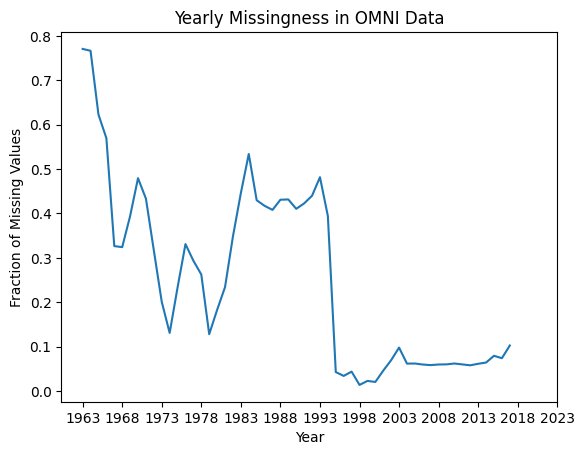

In [12]:
yearly_missingness = (df.isna().groupby(df['year']).mean().mean(axis=1))
yearly_missingness.plot(title='Yearly Missingness in OMNI Data', ylabel='Fraction of Missing Values', xlabel='Year', xticks = np.arange(1963, 2024, 5))
plt.show()


As we can see, there a lot more missing values near the initial years with a decrease until late 1970s. Then, we see a rise in missing data between the years 1979 and 1993. Afterwards however, we see good quality data from 1994 to 2017. Even though this is a good plot, it is better to see the missingness of each column over time. This can be accomplished using a heatmap.

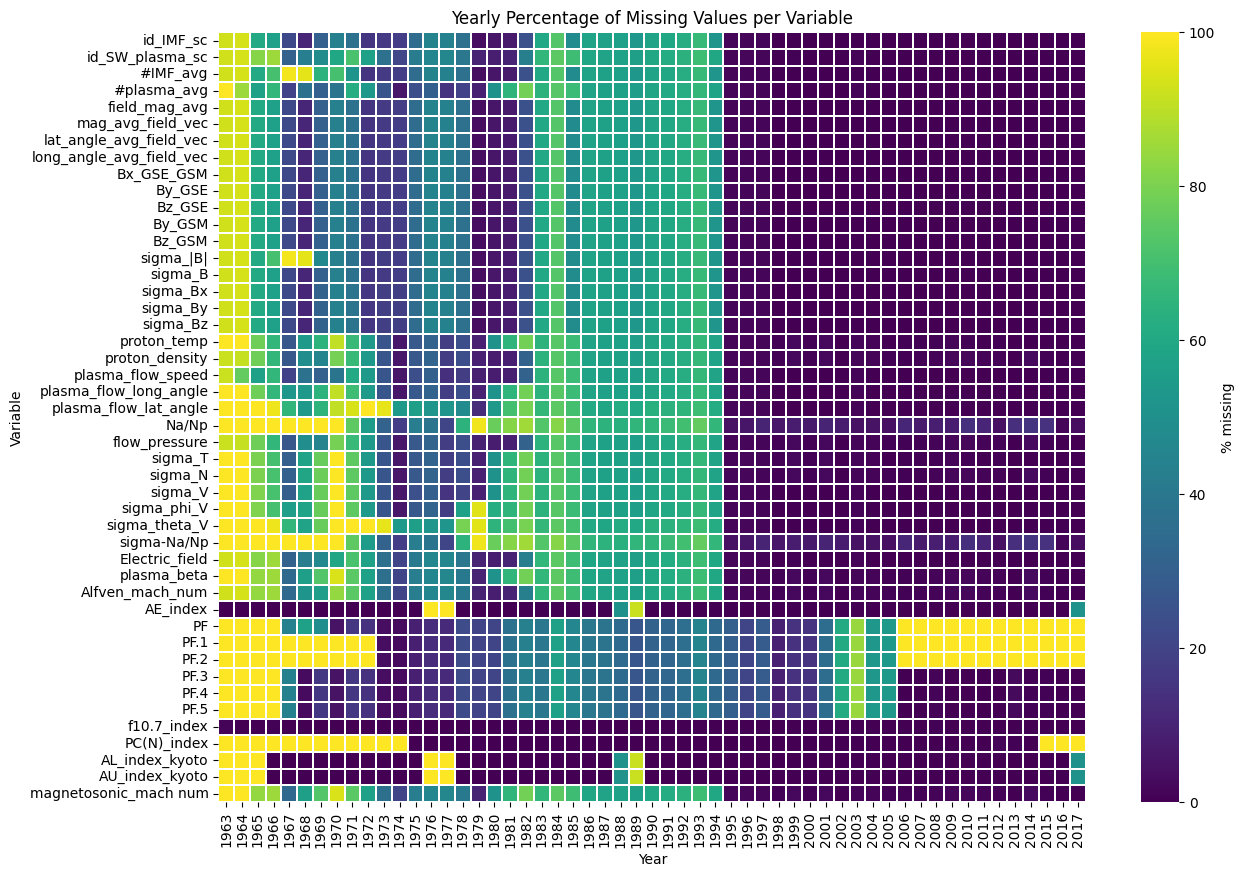

In [13]:
#columns which contained a fraction of missing data
cols = omni_data.columns[omni_data.isna().mean() > 0]

yearly_missing = (omni_data[cols].isna().groupby(omni_data["year"]).mean() * 100)

plt.figure(figsize=(14,10))
sns.heatmap(
    yearly_missing.T,
    cmap="viridis",
    cbar_kws={"label": "% missing"},
    linewidths=0.1
)
plt.xlabel("Year")
plt.ylabel("Variable")
plt.title("Yearly Percentage of Missing Values per Variable")
plt.show()


From this heatmap, we can exactly see what years we have a high percent of fill data for each column. We can see near 100% of data missing in most of the columns in the year 1963 and 1964. We also see that in the years 2006-2017, the PF features (PF, PF.1, PF.2, etc.) are all completely missing. We see that the best coverage of data is between the years 1995 - 2005.

As this is a time series dataset and we want to perform clustering, an interesting thing to see would be the evolution of clusters over time. This heatmap of missing data can help us make decision on segmenting time and seeing the evolution of clusters.

This will help us in performing imputations later on, or we can decide to divide the years into segment. 

First let's also see the behavior of actual values over time. To do this, we look at the counts of observations collected by each spacecraft as denoted by their IDs.

In [14]:
#IMF spacecraft id counts
print("IMF Spacecraft:", "\n" ,omni_data.groupby("id_IMF_sc").size())
#SW Plasma Spacecrafts counts
print("SW Plasma Spacecrafts:", "\n", omni_data.groupby("id_SW_plasma_sc").size())

IMF Spacecraft: 
 id_IMF_sc
1.0      14937
10.0      1757
13.0     31898
18.0      1215
28.0      6233
33.0      8032
34.0      5888
35.0      2811
41.0      7373
43.0      8687
47.0      1645
50.0     66437
51.0    156816
60.0       157
71.0     44779
dtype: int64
SW Plasma Spacecrafts: 
 id_SW_plasma_sc
1.0       2787
3.0       3149
5.0       1625
11.0        55
13.0     23148
18.0      1214
33.0      4920
34.0      2213
35.0      3474
43.0      6645
44.0      6364
45.0      7349
47.0       122
50.0     63023
51.0    158385
60.0       211
71.0     41754
97.0      4390
98.0        56
dtype: int64


We can also understand the distributions of individual features using summary statistics as well as histograms for visualization.

       field_mag_avg  mag_avg_field_vec  ...  AU_index_kyoto  magnetosonic_mach num
count  358665.000000      358665.000000  ...   421440.000000          309270.000000
mean        6.258375           5.567738  ...       78.597525               5.646730
std         3.195272           3.077689  ...       72.923477               1.128801
min         0.400000           0.100000  ...     -529.000000               0.000000
25%         4.200000           3.600000  ...       27.000000               4.900000
50%         5.600000           4.900000  ...       54.000000               5.700000
75%         7.400000           6.700000  ...      107.000000               6.400000
max        62.000000          60.700000  ...     1580.000000              12.700000

[8 rows x 46 columns]


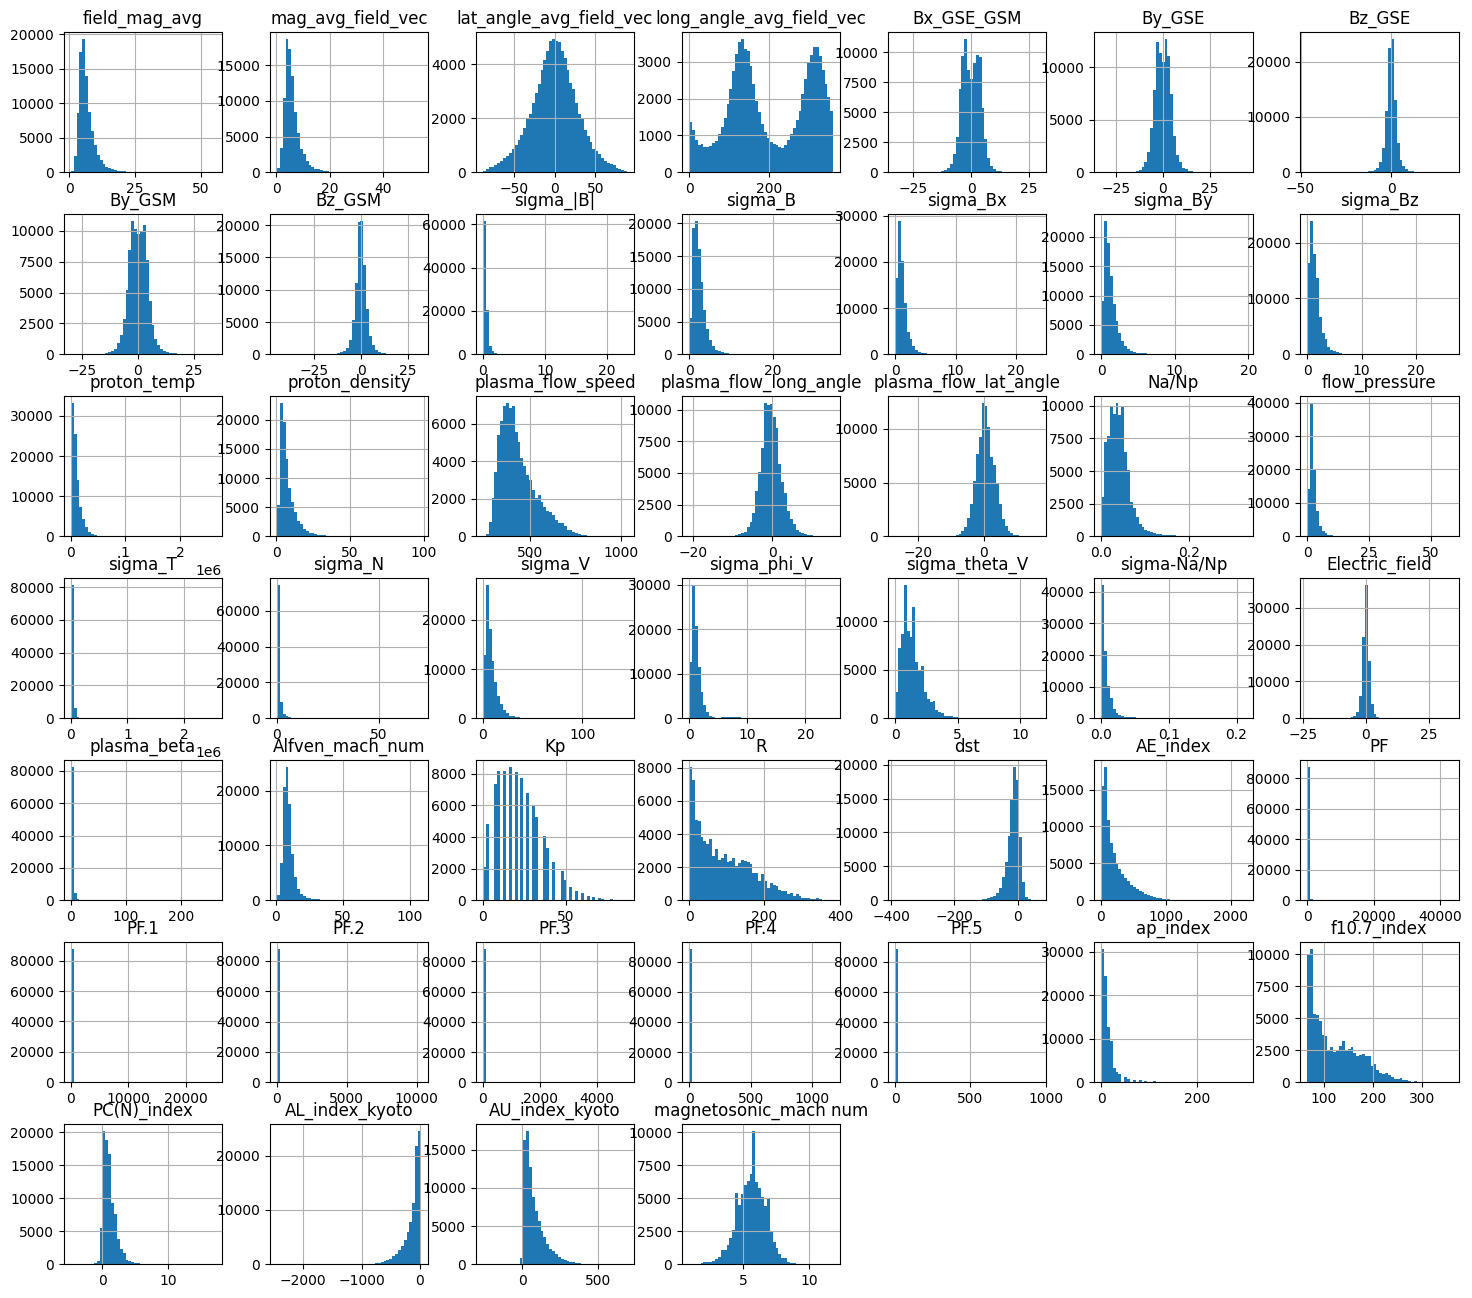

In [15]:
#metdata and id columns:

#Bartels_rotation_num is a metadata column, segmenting days in 27-day rotationsm
#id_IMF_sc and id_SW_plasma_sc are spacecraft ID columns
# #IMF and #plasma average count columns (#IMF_avg, #plasma_avg) indicate the number of spacecraft measurements used to compute the hourly averages for IMF and plasma parameters respectively.
#flag column indicates the data quality based on the metrics provided in the OMNI data documentation [1].
not_actual_vars = ['year', 'day', 'hour', 'Bartels_rotation_num', 'id_IMF_sc', 'id_SW_plasma_sc', '#IMF_avg', '#plasma_avg', 'flag'] 
actual_vars = [col for col in omni_data.columns if col not in not_actual_vars]

omni_data[actual_vars].dropna().hist(
    bins=50, figsize=(18,16)
)

print(omni_data[actual_vars].describe())

We see some nice distributions here, notably the directional magnetic field values Bx, By, Bz as well as plasma flow features follow Gaussian distributions.

From this, another thing to visualize would be the correlations of each features. Many features seem to follow similar distributions. We should look at the correlation of the features, as well as see the behavior of all the features over time.

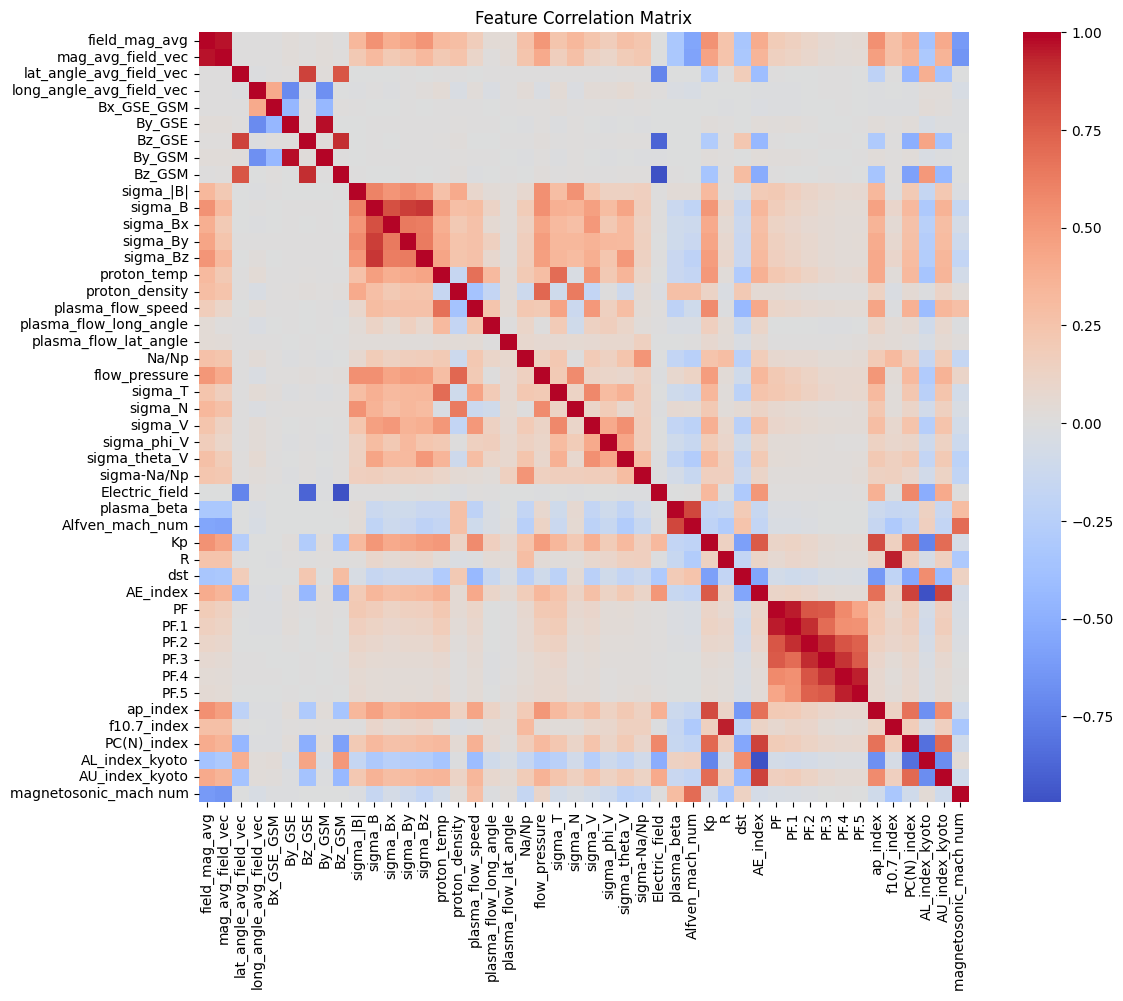

In [ ]:
corr = omni_data[actual_vars].corr(method='pearson') #We use pearson method to only use rows where both the variables are present
plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True
)
plt.title("Feature Correlation Matrix")
plt.show()

As we saw many features having strong correlations, we only need to visualize behaviors of some of those features over time, ignoring the ones they are strongly pairwise correlated with.

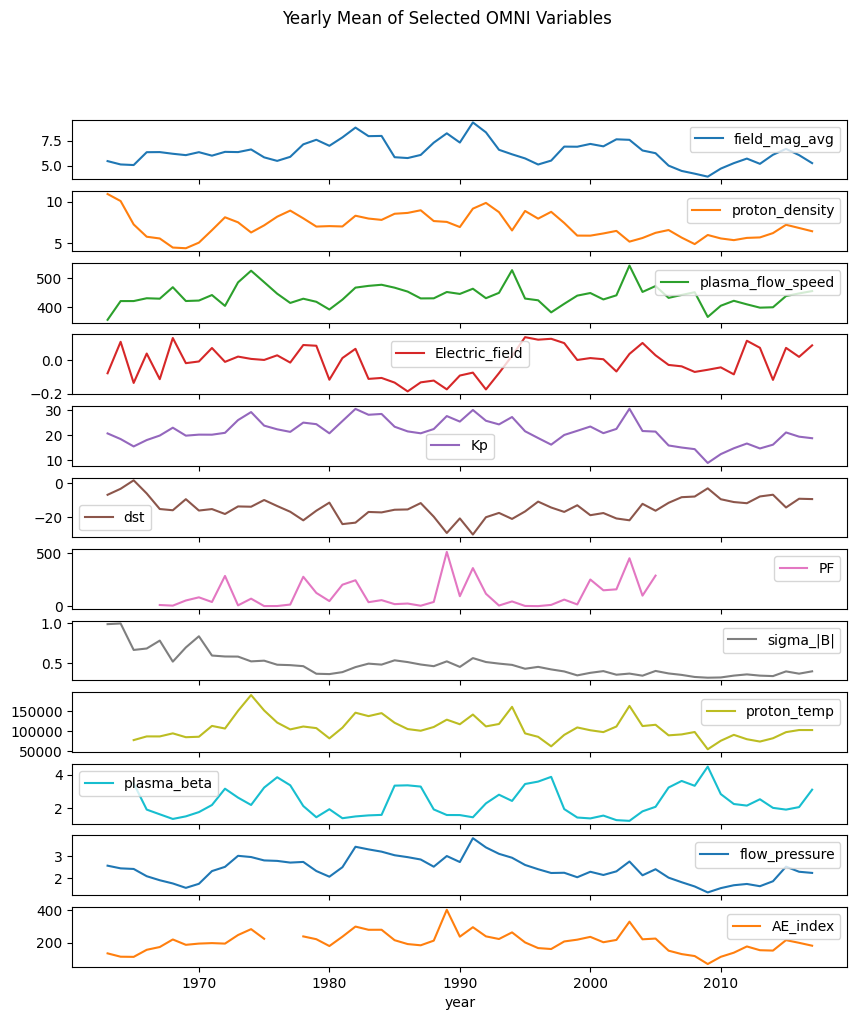

In [ ]:
vars = ['field_mag_avg', 'proton_density', 'plasma_flow_speed', 'Electric_field', 'Kp', 'dst', 'PF','sigma_|B|', 'proton_temp', 'plasma_beta', 'flow_pressure', 'AE_index']
yearly_stats = omni_data.groupby('year')[vars].agg(["mean", "std"])
yearly_stats.xs("mean", axis=1, level=1).plot(subplots=True, figsize=(10, len(vars) - 1), title="Yearly Mean of Selected OMNI Variables")
plt.show()


As we can see, a lot of these features follow similar trends in fluctuations over time.

### 2. Preprocessing

With this time series data, simple yearly mean/median imputation does not make sense. 

IMF and plasma data are sourced independently in OMNI, often from different spacecraft, which is why there are separate spacecraft ID columns and different missingness patterns across variable [1]. It is important to know which features in our datasets are recorded by which spacecrafts (either IMF spacecrafts or SW_plasma spacecrafts) and which features are derived from ground data itself. We also know that there are many derived features, saving us on our feature engineering implementation steps. 

For example, flow_pressure is derived using featuressuch as proton density, plasma flow speed, etc. 

Below is a nice table explaining everything.

| Category | Columns | Data Source / Governing ID | Notes |
|---|---|---|---|
| **Time & Metadata** | year, day, hour | — | Used to construct datetime index |
|  | Bartels_rotation_num | — | Solar rotation metadata |
|  | flag | — | Data quality flag (diagnostic only) |
| **Spacecraft IDs & Averaging Metadata** | id_IMF_sc | IMF spacecraft ID | Identifies spacecraft providing magnetic field data |
|  | id_SW_plasma_sc | Plasma spacecraft ID | Identifies spacecraft providing plasma data |
|  | #IMF_avg | IMF metadata | Number of IMF samples averaged |
|  | #plasma_avg | Plasma metadata | Number of plasma samples averaged |
| **IMF (Magnetic Field) Measurements** | Bx_GSE_GSM, By_GSE, Bz_GSE, By_GSM, Bz_GSM | id_IMF_sc | Primary magnetometer components |
|  | field_mag_avg, mag_avg_field_vec | id_IMF_sc | Magnetic field magnitude |
|  | lat_angle_avg_field_vec, long_angle_avg_field_vec | id_IMF_sc | Magnetic field direction angles |
| **IMF Uncertainty Diagnostics** | sigma_\|B\|, sigma_B, sigma_Bx, sigma_By, sigma_Bz | id_IMF_sc | Measurement uncertainty (typically not used as clustering features) |
| **Solar Wind Plasma Measurements** | proton_density, proton_temp, plasma_flow_speed | id_SW_plasma_sc | Primary plasma quantities |
|  | plasma_flow_long_angle, plasma_flow_lat_angle | id_SW_plasma_sc | Plasma flow direction |
|  | Na/Np | id_SW_plasma_sc | Alpha-to-proton ratio |
| **Derived Plasma Quantities** | flow_pressure | id_SW_plasma_sc | Derived from density & speed |
|  | Electric_field | Mixed (IMF + plasma) | Derived from plasma flow and IMF |
|  | plasma_beta | Mixed (IMF + plasma) | Depends on plasma and magnetic field magnitude |
|  | Alfven_mach_num | Mixed (IMF + plasma) | Depends on plasma and magnetic field |
|  | magnetosonic_mach num | Mixed (IMF + plasma) | Depends on plasma and magnetic field |
| **Plasma Uncertainty Diagnostics** | sigma_T, sigma_N, sigma_V, sigma_phi_V, sigma_theta_V, sigma-Na/Np | id_SW_plasma_sc | Plasma uncertainty estimates |
| **Ground-Based Geomagnetic Indices** | AE_index | Ground-based | Auroral electrojet index |
|  | AL_index_kyoto, AU_index_kyoto | Ground-based | Auroral lower/upper indices |
|  | Kp | Ground-based | Planetary geomagnetic index |
|  | dst | Ground-based | Ring current strength index |
|  | ap_index | Ground-based | Linear planetary index |
|  | PC(N)_index | Ground-based | Polar cap index |
|  | R | Ground-based | Sunspot number |
|  | f10.7_index | Ground-based | Solar radio flux proxy |
| **PF Variables (Derived / OMNI-specific)** | PF, PF.1, PF.2, PF.3, PF.4, PF.5 | Derived (mixed sources) | Often high missingness; validate before using |

Key Notes
- IMF variables are tied to id_IMF_sc; plasma variables are tied to id_SW_plasma_sc.
- IMF and plasma may come from different spacecraft at the same timestamp.
- Spacecraft IDs and #*_avg fields are metadata and should not be used as clustering features.
- Ground-based indices are independent of spacecraft IDs and should not be interpolated.



We can condense the year, day, and hour columns into a single datetime index.

In [ ]:
#set the year, day, hour columns to numeric types to convert to datetime
omni_data['year'] = pd.to_numeric(omni_data['year'], errors='coerce').astype('Int64')
omni_data['day']  = pd.to_numeric(omni_data['day'],  errors='coerce').astype('Int64')
omni_data['hour'] = pd.to_numeric(omni_data['hour'], errors='coerce').astype('Int64')


omni_data['datetime'] = (pd.to_datetime(df['year'], format='%Y') + pd.to_timedelta(df['day'] - 1, unit='D') + pd.to_timedelta(df['hour'], unit='h'))

#set datetime as the actual index and sort the data by datetime
omni_data = omni_data.set_index('datetime').sort_index()
#drop the original year, day. hour columns along with Bartels_rotation_num and flag columns
drop_cols = [
    # time / metadata
    "year","day","hour","Bartels_rotation_num","flag",

    # spacecraft IDs & averaging metadata
    "#IMF_avg","#plasma_avg",

    # uncertainty diagnostics
    "sigma_|B|","sigma_B","sigma_Bx","sigma_By","sigma_Bz",
    "sigma_T","sigma_N","sigma_V","sigma_phi_V","sigma_theta_V","sigma-Na/Np",

    # PF variables (initially)
    "PF","PF.1","PF.2","PF.3","PF.4","PF.5"
]

omni_data = omni_data.drop(columns=[c for c in drop_cols if c in omni_data.columns])

#### Important:
For initial clustering, we will only consider time periods where most data is present (1995-2005). We arrived at this time period by looking at yearly missingness heatmap above.

In [ ]:
omni_data95_05 = omni_data.loc['1995':'2005'].copy()

Windowing: Even though we are working only with data from 1995-2005, we are dealing with an enormous volume of data. We can analyze trends better by windowing samples [2]. Here, we can pick the window size as 24, representing a 24-hour period. Below, we filter out windows which have too many missing values, then interpolate the data in each window for consistency.

In [19]:
WINDOW = 24
STRIDE = 6
MAX_NAN = 0.20

good_windows = []
window_times = []

for i in range(0, len(omni_data95_05) - WINDOW, STRIDE):
    w = omni_data95_05.iloc[i:i+WINDOW]
    if w.isna().mean().mean() <= MAX_NAN:
        good_windows.append(w.copy())
        window_times.append(w.index[0])


# safe columns to interpolate

IMF_COLS = [
    "Bx_GSE_GSM","By_GSE","Bz_GSE",
    "By_GSM","Bz_GSM","field_mag_avg"
]

PLASMA_SMOOTH_COLS = ["plasma_flow_speed"]

def interpolate_window(w):
    # Make sure window is sorted by time
    w = w.sort_index()

    # IMF: interpolate within each IMF spacecraft segment
    imf_interp = (
        w.groupby("id_IMF_sc", group_keys=False)[IMF_COLS]
         .apply(lambda g: g.sort_index().interpolate(method="linear", limit=3, limit_direction="both"))
    )
    w.loc[:, IMF_COLS] = imf_interp

    # Plasma speed: interpolate within each plasma spacecraft segment
    plasma_interp = (
        w.groupby("id_SW_plasma_sc", group_keys=False)[PLASMA_SMOOTH_COLS]
         .apply(lambda g: g.sort_index().interpolate(method="linear", limit=2, limit_direction="both"))
    )
    w.loc[:, PLASMA_SMOOTH_COLS] = plasma_interp

    return w

good_windows = [interpolate_window(w) for w in good_windows]


We no longer need the spacecraft IDs now that the data is interpolated. Let's drop those and see what a sample window looks like.

In [21]:
##Dropping spacecraft id columns after interpolation

ID_COLS = ["id_IMF_sc", "id_SW_plasma_sc"]

good_windows = [
    w.drop(columns=[c for c in ID_COLS if c in w.columns])
    for w in good_windows
]

print(good_windows[0].info())
print("Number of Good windows between11995-2005", len(good_windows))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 1995-01-01 00:00:00 to 1995-01-01 23:00:00
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   field_mag_avg             24 non-null     float64
 1   mag_avg_field_vec         24 non-null     float64
 2   lat_angle_avg_field_vec   24 non-null     float64
 3   long_angle_avg_field_vec  24 non-null     float64
 4   Bx_GSE_GSM                24 non-null     float64
 5   By_GSE                    24 non-null     float64
 6   Bz_GSE                    24 non-null     float64
 7   By_GSM                    24 non-null     float64
 8   Bz_GSM                    24 non-null     float64
 9   proton_temp               24 non-null     float64
 10  proton_density            24 non-null     float64
 11  plasma_flow_speed         24 non-null     float64
 12  plasma_flow_long_angle    24 non-null     float64
 13  plasma_flow_lat_angle     24 

Finally, we can compute window-level statistics. We can then perform imputation of missing values using these windowed metrics (unless there are too many feature-level missing values, in which case we discard the window). Our dataset will now consist solely of these windows.

In [22]:
def summarize_window(w: pd.DataFrame) -> dict:
    feats = {}
    for col in w.columns:
        x = w[col]

        feats[f"{col}_mean"] = x.mean()
        feats[f"{col}_std"]  = x.std()
        feats[f"{col}_min"]  = x.min()
        feats[f"{col}_max"]  = x.max()
        feats[f"{col}_q10"] = x.quantile(0.10)

    return feats

X_feats = pd.DataFrame([summarize_window(w) for w in good_windows],
                       index=pd.to_datetime(window_times)).sort_index()

print("Feature matrix shape:", X_feats.shape)
X_feats.head()


# drop features that are too missing across windows (tune threshold if needed)
MAX_FEAT_NAN = 0.30
X_feats = X_feats.loc[:, X_feats.isna().mean() < MAX_FEAT_NAN]

# median imputation (safe at feature level)
X_feats = X_feats.fillna(X_feats.median())

print("After feature filtering:", X_feats.shape)


Feature matrix shape: (15922, 145)
After feature filtering: (15922, 145)


Now, we are ready to learn the clusters. As a last step, we can obtain a scatterplot of the data points by using PCA to project the data onto 2 dimensions.

Explained variance ratios (first 20 pcs): [0.31430406 0.15559309 0.10159977 0.05463872 0.03512635 0.0312365
 0.02820616 0.02447801 0.02282284 0.01662637 0.01539268 0.01369951
 0.01216529 0.01204829 0.01089862 0.00983245 0.00880084 0.00845485
 0.00743839 0.00731494]


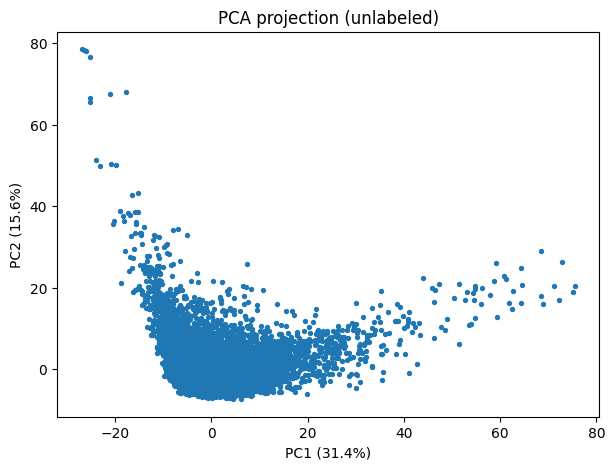

In [39]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_feats)

pca = PCA(n_components=20, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratios (first 20 pcs):", pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA projection (unlabeled)")
plt.show()

Later on, we will see these data points assigned to a label, with each point colored by label to visualize the clusters.

### 3. Clustering

#### Model 1: _K_-Means Clustering

_K_-means clustering is an iterative algorithm that assigns all datapoints to exactly 1 of _K_ clusters. Here, we implement the algorithm on the OMNI 2 dataset, searching for the optimal value of _K_ between 2 and 19. We characterize the "tightness" of the clusters using their inertia, which is the sum of squared distances between samples and the centroid of the cluster they belong to.

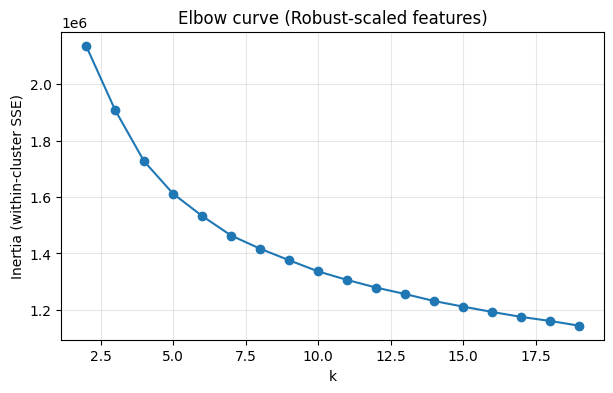

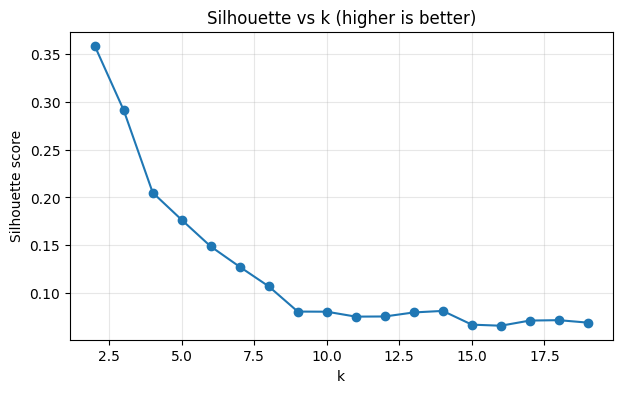

In [44]:
K_RANGE = range(2, 20)  # adjust if you want broader search

rng = np.random.default_rng(0)

inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=0, 
        max_iter=500
    )
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    

# Plot elbow + silhouette
plt.figure(figsize=(7,4))
plt.plot(list(K_RANGE), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow curve (Robust-scaled features)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(K_RANGE), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (higher is better)")
plt.grid(True, alpha=0.3)
plt.show()


The optimal value of _K_ is found using the elbow method. Above, we plot the inertia vs. the search range of _K_ values. We also utilize sihouette analysis, which quantifies the distance between clusters. We pick the point where the decrease in intertia diminishes the fastest. It looks like $K = 6$ is optimal.

Now that we have our chosen _K_, we can go ahead and actually cluster the dataset. Our work below yields summary statistics about each cluster, including counts per cluster and feature-wise distribution statistics on each cluster. We also visualize the clusters, again using PCA for 2D projection. Finally, we show the top distinguishing features by cluster.

Cluster counts:
cluster
0    7557
1     107
2     754
3    3208
4    1032
5    3264
Name: count, dtype: int64


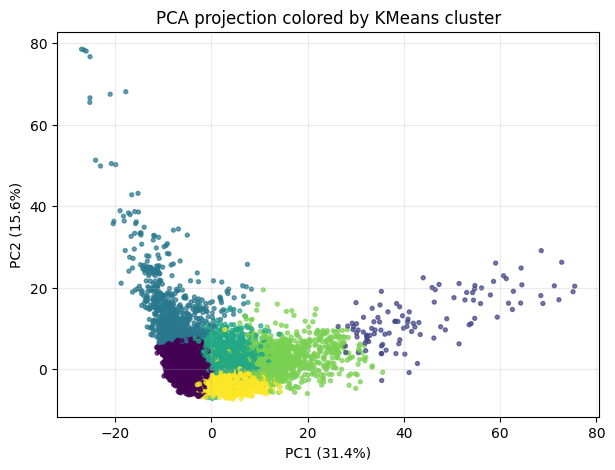

,field_mag_avg_mean,field_mag_avg_std,field_mag_avg_min,field_mag_avg_max,field_mag_avg_q10,mag_avg_field_vec_mean,mag_avg_field_vec_std,mag_avg_field_vec_min,mag_avg_field_vec_max,mag_avg_field_vec_q10,lat_angle_avg_field_vec_mean,lat_angle_avg_field_vec_std,lat_angle_avg_field_vec_min,lat_angle_avg_field_vec_max,lat_angle_avg_field_vec_q10,long_angle_avg_field_vec_mean,long_angle_avg_field_vec_std,long_angle_avg_field_vec_min,long_angle_avg_field_vec_max,long_angle_avg_field_vec_q10,Bx_GSE_GSM_mean,Bx_GSE_GSM_std,Bx_GSE_GSM_min,Bx_GSE_GSM_max,Bx_GSE_GSM_q10,By_GSE_mean,By_GSE_std,By_GSE_min,By_GSE_max,By_GSE_q10,Bz_GSE_mean,Bz_GSE_std,Bz_GSE_min,Bz_GSE_max,Bz_GSE_q10,By_GSM_mean,By_GSM_std,By_GSM_min,By_GSM_max,By_GSM_q10,...,dst_mean,dst_std,dst_min,dst_max,dst_q10,AE_index_mean,AE_index_std,AE_index_min,AE_index_max,AE_index_q10,ap_index_mean,ap_index_std,ap_index_min,ap_index_max,ap_index_q10,f10.7_index_mean,f10.7_index_std,f10.7_index_min,f10.7_index_max,f10.7_index_q10,PC(N)_index_mean,PC(N)_index_std,PC(N)_index_min,PC(N)_index_max,PC(N)_index_q10,AL_index_kyoto_mean,AL_index_kyoto_std,AL_index_kyoto_min,AL_index_kyoto_max,AL_index_kyoto_q10,AU_index_kyoto_mean,AU_index_kyoto_std,AU_index_kyoto_min,AU_index_kyoto_max,AU_index_kyoto_q10,magnetosonic_mach num_mean,magnetosonic_mach num_std,magnetosonic_mach num_min,magnetosonic_mach num_max,magnetosonic_mach num_q10
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,5.086124,0.808977,3.730065,6.657073,4.161542,4.576317,0.958646,2.664616,6.327564,3.460544,0.263962,22.196485,-42.998597,42.317851,-26.438149,200.093282,62.046371,69.650615,285.706100,124.385316,-0.049890,1.718235,-3.162578,3.058237,-2.125159,0.069034,1.730082,-3.103361,3.235451,-2.010019,0.060971,1.597525,-2.984835,3.070610,-1.860930,0.066264,1.718066,-3.100198,3.210123,-2.003857,...,-9.089470,5.040283,-18.237660,-0.413789,-15.362644,129.998682,88.166827,34.902342,355.317454,47.193847,6.044661,2.986369,2.599709,11.528252,2.865251,118.055138,1.399792,116.554056,119.565092,116.554056,0.720383,0.476914,-0.016170,1.752508,0.190093,-77.200818,65.857777,-252.084954,-10.566230,-162.972780,52.713582,30.261256,16.016541,126.976313,22.681408,5.727623,0.457926,4.911764,6.552759,5.174597
1,18.983022,10.388858,6.574766,38.965421,8.313458,16.780841,9.923961,4.646729,37.134579,6.847757,-1.632477,33.913525,-66.244860,56.423364,-43.990935,180.662889,85.132356,41.286916,317.114019,82.868598,0.131114,6.592855,-12.343925,13.072897,-7.048598,1.906659,10.424589,-16.172897,23.242056,-10.070187,-0.640109,11.050838,-24.678505,18.742991,-14.093458,1.964759,9.893898,-16.453271,21.759813,-9.183271,...,-100.495327,61.466904,-215.644860,-15.205607,-182.993458,616.647196,407.528214,123.289720,1579.242991,195.070093,104.144860,80.175131,21.130841,243.327103,24.430841,161.745794,3.534866,158.009346,165.605607,158.009346,3.702843,3.108813,-1.095327,10.835514,0.510935,-434.829050,350.407235,-1361.242991,-59.364486,-851.757944,181.821262,140.728178,-32.093458,528.663551,43.309346,4.654712,1.363874,2.385981,7.251402,3.036075
2,3.993761,1.401877,1.633865,6.604515,2.334183,3.536648,1.457833,1.042497,6.232537,1.793652,-1.859967,26.118831,-52.859097,48.074104,-33.176268,193.168258,83.638215,45.338247,322.249137,91.296414,-0.031780,1.788433,-3.168127,3.189509,-2.189602,0.143723,2.015401,-3.574635,3.672377,-2.312550,-0.092804,1.507027,-3.124170,2.803718,-1.851408,0.135938,1.974798,-3.520584,3.609296,-2.263718,...,-2.036078,5.983564,-12.555113,8.171315,-9.433201,106.371459,77.107448,30.135458,314.001328,39.460956,5.657537,3.023145,2.292165,11.383798,2.530412,88.222045,0.730802,87.437450,89.010226,87.437450,0.557249,0.374754,0.024303,1.413944,0.163798,-61.186587,58.012933,-223.871182,-7.912351,-135.843028,44.970064,26.005813,15.123506,112.053121,20.490837,6.442719,0.604859,5.358566,7.405046,5.708260
3,8.459180,2.056814,5.368308,12.358180,6.163397,7.656518,2.178448,3.892521,11.753755,5.219034,4.647694,27.679262,-4

   cluster                                       top_features
0        0  [proton_temp_max, proton_temp_mean, proton_tem...
1        1  [proton_temp_max, proton_temp_std, proton_temp...
2        2  [proton_temp_max, proton_temp_mean, proton_tem...
3        3  [proton_temp_max, proton_temp_std, proton_temp...
4        4  [proton_temp_max, proton_temp_std, proton_temp...


In [ ]:
K_CHOSEN = 6  
kmeans = KMeans(n_clusters=K_CHOSEN, n_init=50, random_state=0)
labels = kmeans.fit_predict(X_scaled)

# Attach labels to your window feature frame
X_labeled = X_feats.copy()
X_labeled["cluster"] = labels

print("Cluster counts:")
print(X_labeled["cluster"].value_counts().sort_index())

# -----------------------------
# 4) PCA visualization (2D) colored by cluster
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=8, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA projection colored by KMeans cluster")
plt.grid(True, alpha=0.25)
plt.show()

# -----------------------------
# 5) Cluster centroids back in original feature units (approx)
# -----------------------------
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=X_feats.columns)
centroids_df.index.name = "cluster"

# Optional: show a few centroid rows
display(centroids_df.head())

# -----------------------------
# 6) "Top distinguishing features" per cluster (simple, useful)
#    For each cluster, find features where centroid differs most from global median
# -----------------------------
global_med = X_feats.median()

top_features = {}
for c in range(K_CHOSEN):
    diff = (centroids_df.loc[c] - global_med).abs().sort_values(ascending=False)
    top_features[c] = diff.head(12).index.tolist()

top_features_df = pd.DataFrame({
    "cluster": list(top_features.keys()),
    "top_features": [top_features[c] for c in top_features]
})

print(top_features_df.head())

There is a lot to be gleaned from above. First of all, we can see that the clusters are not balanced, with their sizes ranging from 107 to 7557. Next, the PCA projection shows clearly distinguishable clusters, although some samples are obscured from view by others.

Looking at the feature statistics per cluster, it appears that feature values are widely different across clusters. This suggests that samples in one cluster are substantially different from samples in other clusters, which is desirable.

Interestingly, the dominant distinguishing feature in all clusters is related to proton_temp.

#### Model 2: _K_-Medians Clustering

_K_-medians clustering is very similar to _K_-means clustering, except that instead of computing the mean centroid of each cluster, we compute the median centroid. This technique involves minimizing the sum of L1 (Manhattan) distances of samples in each cluster. Below, we have implemented our own function for _K_-medians clustering.

In [41]:
def _manhattan_dist(X, C):
    # X: (n, d), C: (k, d) -> returns (n, k)
    return np.abs(X[:, None, :] - C[None, :, :]).sum(axis=2)

def kmedians(X, k, n_init=10, max_iter=200, tol=1e-4, random_state=0, verbose=False):
    """
    K-medians clustering (L1). Returns best solution over n_init restarts.
    X should be numpy array shape (n_samples, n_features).
    """
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    n, d = X.shape

    best_inertia = np.inf
    best_labels = None
    best_centers = None

    for init in range(n_init):
        # init centers by choosing k random points
        idx = rng.choice(n, size=k, replace=False)
        centers = X[idx].copy()

        prev_inertia = np.inf

        for it in range(max_iter):
            # assign
            D = _manhattan_dist(X, centers)
            labels = D.argmin(axis=1)

            # update (coordinate-wise median)
            new_centers = centers.copy()
            for j in range(k):
                mask = labels == j
                if not np.any(mask):
                    # empty cluster: re-seed to farthest point from its assigned center
                    farthest = np.argmax(D.min(axis=1))
                    new_centers[j] = X[farthest]
                else:
                    new_centers[j] = np.median(X[mask], axis=0)

            centers = new_centers

            # objective: sum L1 distances to assigned center
            inertia = np.sum(np.abs(X - centers[labels]).sum(axis=1))

            if verbose and (it % 10 == 0 or it == max_iter - 1):
                print(f"init {init+1}/{n_init}, iter {it}, L1 inertia={inertia:.3e}")

            # convergence check
            if abs(prev_inertia - inertia) <= tol * (prev_inertia + 1e-12):
                break
            prev_inertia = inertia

        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels
            best_centers = centers

    return best_labels, best_centers, best_inertia


Now that we have defined _K_-medians, we can search for the optimal number of clustering, again by making use of the elbow method.

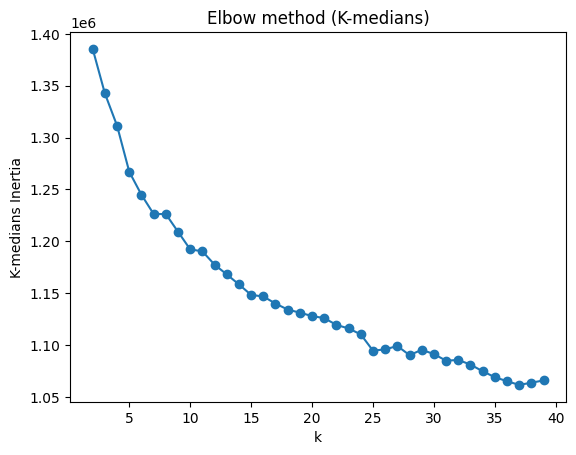

In [45]:
#Running kmedian on the dataset
ks = range(2, 40)
inertias = []

for k in ks:
    labels, centers, inertia = kmedians(X_scaled, k=k, n_init=5, max_iter=500, random_state=42)
    inertias.append(inertia)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(list(ks), inertias, marker='o')
plt.xlabel("k")
plt.ylabel("K-medians Inertia")
plt.title("Elbow method (K-medians)")
plt.show()


The curve of intertia vs. _K_ is a bit smooth and doesn't have a sharp elbow point. Let's pick $K = 10$.

As before, we can actually perform clustering using our chosen _K_. We can produce the same output as with _K_-means: counts per cluster, feature-wise statistics, PCA projection, and most distinguishing features.

Cluster counts (K-medians):
cluster
0    1225
1     829
2     859
3     388
4    1278
5     767
6    3308
7    2075
8    2328
9    2865
Name: count, dtype: int64


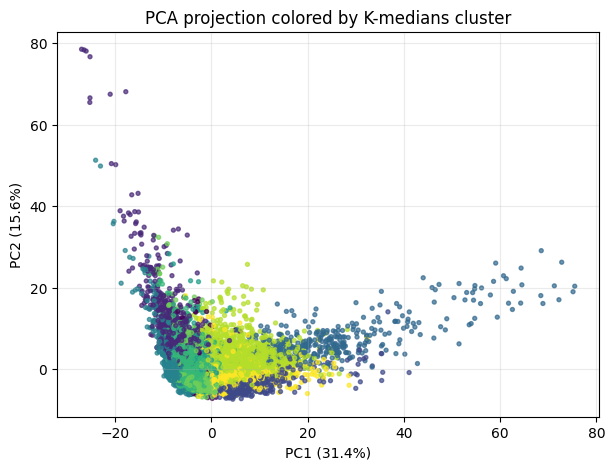

,field_mag_avg_mean,field_mag_avg_std,field_mag_avg_min,field_mag_avg_max,field_mag_avg_q10,mag_avg_field_vec_mean,mag_avg_field_vec_std,mag_avg_field_vec_min,mag_avg_field_vec_max,mag_avg_field_vec_q10,lat_angle_avg_field_vec_mean,lat_angle_avg_field_vec_std,lat_angle_avg_field_vec_min,lat_angle_avg_field_vec_max,lat_angle_avg_field_vec_q10,long_angle_avg_field_vec_mean,long_angle_avg_field_vec_std,long_angle_avg_field_vec_min,long_angle_avg_field_vec_max,long_angle_avg_field_vec_q10,Bx_GSE_GSM_mean,Bx_GSE_GSM_std,Bx_GSE_GSM_min,Bx_GSE_GSM_max,Bx_GSE_GSM_q10,By_GSE_mean,By_GSE_std,By_GSE_min,By_GSE_max,By_GSE_q10,Bz_GSE_mean,Bz_GSE_std,Bz_GSE_min,Bz_GSE_max,Bz_GSE_q10,By_GSM_mean,By_GSM_std,By_GSM_min,By_GSM_max,By_GSM_q10,...,dst_mean,dst_std,dst_min,dst_max,dst_q10,AE_index_mean,AE_index_std,AE_index_min,AE_index_max,AE_index_q10,ap_index_mean,ap_index_std,ap_index_min,ap_index_max,ap_index_q10,f10.7_index_mean,f10.7_index_std,f10.7_index_min,f10.7_index_max,f10.7_index_q10,PC(N)_index_mean,PC(N)_index_std,PC(N)_index_min,PC(N)_index_max,PC(N)_index_q10,AL_index_kyoto_mean,AL_index_kyoto_std,AL_index_kyoto_min,AL_index_kyoto_max,AL_index_kyoto_q10,AU_index_kyoto_mean,AU_index_kyoto_std,AU_index_kyoto_min,AU_index_kyoto_max,AU_index_kyoto_q10,magnetosonic_mach num_mean,magnetosonic_mach num_std,magnetosonic_mach num_min,magnetosonic_mach num_max,magnetosonic_mach num_q10
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,6.600000,1.006276,5.0,8.7,5.43,6.037500,1.160951,3.8,8.3,4.650,0.841667,21.878638,-41.20,43.00,-24.40,135.037500,30.529544,76.00,195.10,98.420,-2.366667,1.767808,-5.2,1.8,-4.50,3.383333,2.018928,-0.90,6.6,0.960,0.050000,2.176251,-3.90,4.1,-2.560,3.262500,2.047250,-1.2,6.5,0.83,...,-6.041667,5.744405,-17.0,4.0,-13.7,158.375000,111.331435,40.0,447.0,53.00,6.875,3.207498,3.0,12.0,3.6,174.5000,1.459675,171.70,176.70,171.70,0.941667,0.654915,-0.1,2.3,0.20,-85.458333,74.163731,-290.0,-12.0,-186.00,67.583333,41.452872,19.0,174.0,26.3,4.962500,0.484469,4.1,5.8,4.33
1,4.029167,1.113260,2.2,6.3,2.70,3.579167,1.227751,1.3,5.9,2.130,-1.566667,27.138229,-55.80,49.80,-34.50,202.866667,82.234737,34.40,343.60,97.450,0.125000,1.689862,-3.0,3.2,-2.17,-0.245833,1.933341,-3.90,3.4,-2.870,-0.075000,1.522012,-2.90,2.8,-1.840,-0.262500,1.919687,-3.9,3.4,-2.77,...,1.041667,4.957793,-7.0,10.0,-5.0,86.333333,58.696329,27.0,246.0,35.60,4.375,1.769303,2.0,7.0,2.3,77.2500,0.306452,76.70,77.60,76.70,0.475000,0.312047,0.0,1.2,0.13,-46.041667,43.482609,-173.0,-5.0,-100.00,38.166667,20.155914,13.0,89.0,18.0,6.275000,0.438119,5.4,7.0,5.70
2,6.962500,0.930287,5.4,8.9,5.80,5.783333,1.190352,3.4,8.1,4.300,-2.558333,20.118331,-42.10,36.60,-26.70,148.175000,26.329492,100.40,203.60,120.590,-3.608333,1.526095,-6.1,-0.5,-5.21,2.541667,1.944329,-1.60,5.8,0.150,-0.229167,1.868426,-3.90,3.4,-2.500,2.395833,1.933678,-1.8,5.6,0.06,...,-33.875000,7.342427,-49.0,-19.0,-42.8,464.458333,199.915304,143.0,895.0,233.10,28.375,10.929865,15.0,48.0,15.9,117.6000,0.919357,115.50,119.50,115.50,2.041667,0.900563,0.6,4.1,1.03,-314.500000,164.733332,-692.0,-63.0,-514.40,147.333333,52.979470,61.0,265.0,82.6,6.095833,0.480470,5.0,6.9,5.43
3,14.808333,5.636459,6.8,25.1,8.13,13.497917,5.485015,4.7,24.4,6.940,1.187500,32.662682,-62.20,63.50,-41.07,176.935417,79.301859,44.25,332.90,85.640,-0.029167,4.732141,-9.0,8.5,-5.55,1.322917,7.641607,-12.85,16.0,-8.415,0.704167,7.423139,-13.15,14.8,-7.825,1.343750,7.648285,-13.3,16.4,-8.08,...,-46.666667,30.758013,-104.0,6.0,-84.1,432.833333,296.585162,59.0,1115.0,94.65,49.125,37.150416,7.0,111.0,9.9,149.8125,1.379036,147.20,151.10,147.20,2.181250,1.731920,-0.2,5.8,0.30,-281.958333,235.252783,-880.0,-20.0,-594.60,135.541667,94.899493,22.0,354.0,38.1,4.600000,1.069064,2.7,6.5,3.29
4,3.791667,0.510665,2.8,4.8,3.10,3.429167,0.641274,2.0,4.6,2.600,2.947917,18.677800,-32.55,39.35,-18.80,193.054167,42.998308,55.20,335.55,112.460,-0.041667,1.303556,-2.8,2.9,-2.14,-0.264583,1.110437,-2.50,2.3,-1.780,0.15

   cluster                                       top_features
0        0  [proton_temp_max, proton_temp_mean, proton_tem...
1        1  [proton_temp_max, proton_temp_std, proton_temp...
2        2  [proton_temp_max, proton_temp_mean, proton_tem...
3        3  [proton_temp_max, proton_temp_std, proton_temp...
4        4  [proton_temp_max, proton_temp_std, proton_temp...
5        5  [proton_temp_max, proton_temp_mean, proton_tem...


In [48]:
K_CHOSEN_MEDIAN = 10

label_median, centers_median, inertia_median = kmedians(X_scaled, k=K_CHOSEN_MEDIAN, n_init=20, max_iter=500, random_state=0)

X_labeled_median = X_feats.copy()
X_labeled_median["cluster"] = label_median
print("Cluster counts (K-medians):")
print(X_labeled_median["cluster"].value_counts().sort_index())
# -----------------------------
# 4) PCA visualization (2D) colored by cluster (K-medians)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=label_median, s=8, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA projection colored by K-medians cluster")
plt.grid(True, alpha=0.25)
plt.show()

# 5) Cluster centroids back in original feature units (approx) (K-medians)
centroids_scaled_median = centers_median
centroids_median = scaler.inverse_transform(centroids_scaled_median)
centroids_df_median = pd.DataFrame(centroids_median, columns=X_feats.columns)
centroids_df_median.index.name = "cluster"
# Optional: show a few centroid rows
display(centroids_df_median.head(10))

#Top distinguishing features per cluster (K-medians)
global_med = X_feats.median()
top_features_median = {}
for c in range(K_CHOSEN_MEDIAN):
    diff = (centroids_df_median.loc[c] - global_med).abs().sort_values(ascending=False)
    top_features_median[c] = diff.head(12).index.tolist()
top_features_df_median = pd.DataFrame({
    "cluster": list(top_features_median.keys()),
    "top_features": [top_features_median[c] for c in top_features_median]
})


print(top_features_df.head(10))

We can see that the clusters are more balanced. The clusters seem to overlap quite a bit in the PCA projection plot, though they are still distinguishable. Interestingly, even though we have 10 clusters, there is less variation between features across the clusters, and less clarity in the PCA plot. Proton_temp remains the top distinguishing feature for clusters.

### Comparative Analysis

Let's take a look at the intertia for both models again. The inertia for _K_-means is $1.55 \times 10^6$ while the inertia for _K_-medians is $1.19 \times 10^6$. Overall, these are on the same order of magnitude and don't differ too significantly.

The inertia of _K_-medians is higher than that of _K_-means. However, we will ultimately recommend the K-means clustering model instead. The elbow plot curve for _K_-means has a sharper elbow point than that for _K_-medians, indicating that _K_-medians is suboptimal. Furthermore, the PCA projection plot for _K_-means shows more clear clusters compared to _K_-medians, and that too with fewer clusters. In terms of computational complexity, _K_-means again reigns supreme with a faster runtime as _K_-medians involves an expensive median computation. This suggests that the _K_-means clusterer is the most suitable for this dataset.

### Ethical Discussion

As this is a NASA dataset, one ethical consideration would be that the insights gleaned from machine learning could be used to shape decision in future NASA missions, which can cost billions of dollars and involve astronaut lives. It's also important to take stock of how the training ML models on this space dataset will really benefit humanity--in other words, if it is justified to spend large sums of money for space when we should be focusing on issues down on Earth [3]. There is also the environmental impact of training ML models, so, once again, we are paying a price on Earth for a cause that benefits so few humans. Additionally, for satelites that make Earth observations (including the spacecrafts involved in this dataset), it must be ensured that they don't reveal sensitive information pertaining to people on Earth.

### Bibliography

- [1] https://omniweb.gsfc.nasa.gov/html/ow_data.html
- [2] https://www.geeksforgeeks.org/machine-learning/time-series-clustering-techniques-and-applications/
- [3] https://www.nasa.gov/wp-content/uploads/2024/02/white-paper-space-data-ethics-2023-12-01-final-002.pdf?emrc=65d8fcfdca26